# Predict Students' Dropout and Academic Success

### Load Dataset

In [10]:
import pandas as pd 
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# read the CSV file into a pandas DataFrame
# sep=';' is used to specify that the separator in the CSV file is a semicolon
df = pd.read_csv("predict_students'_dropout_and_academic_success.csv", sep=';')

print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (4424, 37)


### Column Names

In [11]:
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)
print("Columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    print(f"{i:2d}. {col:<50} | {dtype}")

Columns in the dataset:
 1. Marital status                                     | int64
 2. Application mode                                   | int64
 3. Application order                                  | int64
 4. Course                                             | int64
 5. Daytime/evening attendance                         | int64
 6. Previous qualification                             | int64
 7. Previous qualification (grade)                     | float64
 8. Nacionality                                        | int64
 9. Mother's qualification                             | int64
10. Father's qualification                             | int64
11. Mother's occupation                                | int64
12. Father's occupation                                | int64
13. Admission grade                                    | float64
14. Displaced                                          | int64
15. Educational special needs                          | int64
16. Debtor                 

### Missing Values Check

In [12]:
error_num = df.isnull().sum()
print("Missing values: ")
print(error_num)

Missing values: 
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                             

### Targets Distribution

Target,Count,Percentage
Graduate,2209,49.93%
Dropout,1421,32.12%
Enrolled,794,17.95%


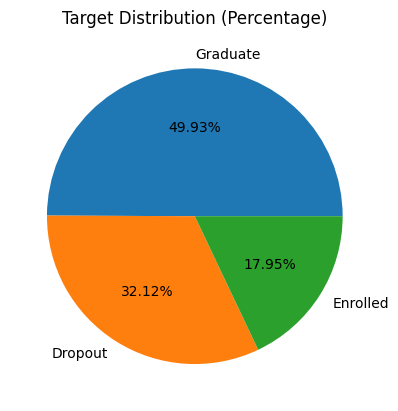

In [13]:
# show the distribution of the target variable in a tabular format
counts = df['Target'].value_counts().reset_index()
counts.columns = ['Target', 'Count']
# add percentage column
counts['Percentage'] = (counts['Count'] / counts['Count'].sum()) * 100
# format percentage to 2 decimal places
counts['Percentage'] = counts['Percentage'].map('{:.2f}%'.format)
display(counts.style.hide(axis="index"))

# show the distribution of the target variable using a pie chart
plt.figure()
counts = df['Target'].value_counts()
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.2f%%'
)
plt.title("Target Distribution (Percentage)")
plt.show()

### Preprocess Dataset

In [14]:
""" LabelEncoder converts categorical labels to numeric labels ->  
sorts categorical labels alphabetically, and assigns integer values starting from 0;
Index = encoded value. """
le = LabelEncoder() 
df["Target"] = le.fit_transform(df["Target"])
mapping = {int(k): v for k, v in zip(le.transform(le.classes_), le.classes_)}
print(f"mapping: {mapping}")


mapping: {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}


### Split Dataset (80% train data + 20% test data)

In [15]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")

X_train.shape: (3539, 36)
y_train.shape: (3539,)
